![img](https://i.imgur.com/1JAZgnG.png?2)

# Shopify Dataset

## Minería de Datos aplicada al Comercio Electrónico

### Análisis Exploratorio, Preprocesamiento, Feature Engineering y Modelado Predictivo

**Universidad Estatal Amazónica (UEA)**

**Carrera:** Tecnología de la Información

**Integrantes:**

- Montoya Zamora Ronnal Eulogio
- Tanguila Vargas Dina María
- Rubio Flores Anthony Sebastian

**Asignatura:** Minería de Datos

**Docente:** Dr. Delfín Bernabé Ortega Tenezaca, Ph.D.

**Fecha:** 26 de junio de 2026


## **Descripción**

Este proyecto busca implementar métodos de minería de datos en un conjunto de datos de Shopify que incluye información acerca de pedidos en comercio electrónico. El conjunto de datos contiene la tienda, el usuario, la fecha de la transacción, el monto de compra, el número de productos adquiridos, el método de pago y el identificador del pedido.
Se ejecutará un análisis exploratorio, después de lo cual se llevará a cabo un preprocesamiento para gestionar registros duplicados, valores nulos y valores atípicos. Después, se implementarán métodos de transformación e ingeniería de atributos. Por último, se emplearán métodos de minería de datos para examinar la conducta de las ventas y detectar patrones.
La investigación de datos facilita la comprensión de las características y conexiones que existen dentro de un conjunto de información antes de utilizar métodos de modelado.



## **Objetivo General**

Aplicar técnicas de minería de datos en un conjunto de datos de Shopify con el objetivo de reconocer patrones significativos.
.


## **Objetivos Específicos**

- Examinar las propiedades del conjunto de datos a través de métodos de análisis exploratorio.
-	Procesar el conjunto de datos a través de la limpieza, la conversión y la ingeniería de las características.
-	Aplicar diversas técnicas de minería de datos para detectar patrones y cotejar su rendimiento.



## **1. Importación de librerías**

Se añaden las librerías esenciales para gestionar, investigar, ilustrar, modelar y analizar el conjunto de datos de Shopify. Estas utilidades facilitan el desarrollo ordenado de las diversas fases del proceso de extracción de datos.

In [1]:
# ============================================
#  IMPORTACIÓN DE LIBRERÍAS
# ============================================

# Manejo y análisis de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# División y validación de datos
from sklearn.model_selection import train_test_split, cross_validate

# Modelos de minería de datos
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Métricas de evaluación
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## **2.** **Carga del Dataset**

Para el análisis que se presenta, se recurrió al archivo Shopify.csv, adquirido de la plataforma Kaggle en junio de 2026. Este archivo fue elegido porque ofrece datos pertinentes al reto de análisis de datos de Shopify, lo que posibilita la utilización de métodos de exploración, depuración, transformación y análisis de datos.
La procedencia del conjunto de datos proviene del siguiente recurso accesible en Kaggle:
Enlace de referencia: https://www.kaggle.com/code/kevnchan/shopify-winter-2019-data-science-challenge#Question-1
Tras su descarga, el archivo Shopify.csv fue subido al entorno de Google Colab, donde se cargó usando código para tener acceso a la información en las distintas fases del proyecto. La adición de la fuente de datos ayuda asegurar la trazabilidad del conjunto de datos, haciendo más fácil la identificación de su origen  y la facilidad de repetir el análisis realizado.



In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/Dinatang/mineria_de_datos/refs/heads/main/Shopify.csv"

df = pd.read_csv(url)

df.head()

,order_id,shop_id,user_id,order_amount,total_items,payment_method,created_at
0,1,53,746,224,2,cash,2017-03-13 12:36:56
1,2,92,925,90,1,cash,2017-03-03 17:38:52
2,3,44,861,144,1,cash,2017-03-14 4:23:56
3,4,18,935,156,1,credit_card,2017-03-26 12:43:37
4,5,18,883,156,1,credit_card,2017-03-01 4:35:11


### Interpretación

La visualización de las cinco primeras entradas facilita confirmar que el archivo Shopify. csv se ha importado  completamente y ayuda a identificar la organización básica del conjunto de datos, que incluye variables sobre pedidos, clientes, tiendas, cantidades, productos, metodos de pago y fechas.

# 3. Valores nulos

Son datos que carecen de información almacenada para un registro o variables especifica dentro de un conjunto de datos. Dado que su presencia puede influir en el rendimiento de los modelos de minería de datos y en el análisis estadístico, es preciso detectarlos y definir si necesitan un tratamiento, como la eliminación, imputación o sustitución.

In [3]:
# ============================================================
# ANÁLISIS DE VALORES NULOS
# ============================================================

nulos = pd.DataFrame({
    'Variable': df.columns,
    'Valores nulos': df.isnull().sum().values,
    'Porcentaje nulos': (df.isnull().mean().values * 100).round(2)
})

display(nulos)

,Variable,Valores nulos,Porcentaje nulos
0,order_id,0,0.0
1,shop_id,0,0.0
2,user_id,0,0.0
3,order_amount,0,0.0
4,total_items,0,0.0
5,payment_method,0,0.0
6,created_at,0,0.0


### Interpretación

Ninguna de las variables del conjunto de datos tiene valores ausentes, como lo demuestra el análisis de los valores nulos. Las 7 variables tienen información total para los 5000 registros, así que no fue necesario emplear métodos de sustitución o supresión de registros debido a valores nulos.


## **4. Descripción de las Características Iniciales del Dataset**

Se examina la estructura general del conjunto de datos en esta sección con el objetivo de determinar cuántos registros hay, cuántas variables y qué tipos de datos tienen, así como si existen valores nulos. Esta revisión posibilita el conocimiento de las propiedades iniciales del conjunto de datos antes de llevar a cabo la exploración analítica.

In [4]:
# ==========================================================
# EXPLORACIÓN GENERAL DEL CONJUNTO DE DATOS
# ==========================================================

# Muestra el número de filas y columnas del DataFrame,
# permitiendo conocer el tamaño del conjunto de datos.
print("Dimensiones del dataset:")
print(df.shape)

# Muestra información detallada del DataFrame, incluyendo:
# - Número de registros.
# - Nombre de las columnas.
# - Tipo de dato de cada variable.
# - Cantidad de valores no nulos.
# - Uso aproximado de memoria.
print("\nInformación del dataset:")
df.info()

Dimensiones del dataset:
(5000, 7)

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   order_id        5000 non-null   int64 
 1   shop_id         5000 non-null   int64 
 2   user_id         5000 non-null   int64 
 3   order_amount    5000 non-null   int64 
 4   total_items     5000 non-null   int64 
 5   payment_method  5000 non-null   object
 6   created_at      5000 non-null   object
dtypes: int64(5), object(2)
memory usage: 273.6+ KB


### Interpretación

El análisis preliminar identifica que el conjunto de datos está compuesto por siete variables(columnas) y 5.000 registros(filas). Todas las variables tienen 5.000 observaciones no nulas, lo que demuestra que no hay valores ausentes en los registros examinados. Las variables order_amount, total_items, user_id, shop_id y order_id están guardadas como datos enteros. Por otro lado, payment_method y created_at fueron clasificadas al principio como variables de tipo objeto.

## **5.** **Identificación de las Variables del Dataset**

En esta parte, se determinan y categorizan las variables que componen el conjunto de datos de Shopify. Identificar sus nombres y categorías posibilita establecer su papel dentro del análisis y elegir cuáles se emplearán en las fases siguientes de modelado y exploración.

In [5]:
# ============================================================
# IDENTIFICACIÓN DE LAS VARIABLES DEL CONJUNTO DE DATOS
# ============================================================

# Muestra los nombres de las variables
print("Variables del dataset:")
print(df.columns)

# Clasificación de las variables
variables = pd.DataFrame({
    'Variable': [
        'order_id',
        'shop_id',
        'user_id',
        'order_amount',
        'total_items',
        'payment_method',
        'created_at'
    ],
    'Tipo de variable': [
        'Identificadora',
        'Identificadora',
        'Identificadora',
        'Numérica',
        'Numérica',
        'Categórica',
        'Temporal'
    ]
})

print("\nClasificación de las variables:")
display(variables)

Variables del dataset:
Index(['order_id', 'shop_id', 'user_id', 'order_amount', 'total_items',
       'payment_method', 'created_at'],
      dtype='object')

Clasificación de las variables:


,Variable,Tipo de variable
0,order_id,Identificadora
1,shop_id,Identificadora
2,user_id,Identificadora
3,order_amount,Numérica
4,total_items,Numérica
5,payment_method,Categórica
6,created_at,Temporal


### Interpretación

Se detectaron siete variables en el conjunto de datos y se clasificaron de acuerdo con su función y su naturaleza. Las variables categóricas y temporales necesitan transformaciones específicas para su uso en el modelado, a diferencia de las variables numéricas que facilitan la realización de análisis estadísticos.

# **6. Estadísticas Descriptivas del Dataset**

Las estadísticas descriptivas ayudan a sintetizar las características clave de las variables numéricas del conjunto de datos a través de medidas de tendencia central, de dispersión y de posición. Estas medidas permiten entender el comportamiento de los datos y  detectar posibles diferencias o valores atípicos antes de utilizar técnicas de minería de datos.

In [6]:
# ============================================================
# ESTADÍSTICAS DESCRIPTIVAS DEL CONJUNTO DE DATOS
# ============================================================

# Seleccionar las variables relevantes
variables_estadisticas = [
    'order_amount',
    'total_items'
]

# Calcular estadísticas descriptivas
estadisticas = df[variables_estadisticas].describe().T

# Renombrar las columnas para facilitar la interpretación
estadisticas = estadisticas.rename(columns={
    'count': 'N',
    'mean': 'Media',
    'std': 'Desviación estándar',
    'min': 'Mínimo',
    '25%': 'Q1 (25%)',
    '50%': 'Mediana (Q2)',
    '75%': 'Q3 (75%)',
    'max': 'Máximo'
})

# Redondear los valores a dos decimales
estadisticas = estadisticas.round(2)

# Mostrar la tabla
display(estadisticas)

,N,Media,Desviación estándar,Mínimo,Q1 (25%),Mediana (Q2),Q3 (75%),Máximo
order_amount,5000.0,3145.13,41282.54,90.0,163.0,284.0,390.0,704000.0
total_items,5000.0,8.79,116.32,1.0,1.0,2.0,3.0,2000.0


### Interpretación
Los resultados corresponden a 5.000 pedidos. El order_amount (cantidad de pedido) muestra una media de 3.145,13 y una mediana de 284,00, lo que demuestra que los valores extremos tienen un impacto en la distribución; el valor máximo es de 704.000,00. El total_items (total de artículos), la media es de 8.79 artículos y la mediana es de 2; el número máximo por pedido asciende a los 2000 artículos. Esto confirma que existe valores atípicos que aumentan los promedios de manera significativa.
Por lo tanto, la mediana muestra una representación más precisa del comportamiento de los pedidos en general, es aconsejable examinar los valores atípicos antes de llegar a conclusiones sobre el comportamiento general de las ventas.

## **7. Identificadores atipicos**
Las observaciones que tienen valores muy distantes del comportamiento general de los datos se denominan valores atípicos. El rango intercuartílico (IQR), obtenido a partir de Q1 y Q3, se usa para identificarlo. Este procedimiento posibilita definir límites estadísticos para identificar las observaciones que no están dentro del rango previsto.

Fórmula:

$$
IQR = Q_3 - Q_1
$$

$$
\text{Límite inferior} = Q_1 - 1.5(IQR)
$$

$$
\text{Límite superior} = Q_3 + 1.5(IQR)
$$

In [7]:
# ============================================================
#  IDENTIFICACIÓN DE VALORES ATÍPICOS
# ============================================================

# Variable que será analizada
variable = 'order_amount'

# Calculamos Q1 y Q3
Q1 = df[variable].quantile(0.25)
Q3 = df[variable].quantile(0.75)

# Calculamos el rango intercuartílico
IQR = Q3 - Q1

# Calculamos los límites para identificar valores atípicos
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Identificamos los valores atípicos
valores_atipicos = df[
    (df[variable] < limite_inferior) |
    (df[variable] > limite_superior)
]

# Cantidad y porcentaje de valores atípicos
cantidad_atipicos = len(valores_atipicos)
porcentaje_atipicos = (cantidad_atipicos / len(df)) * 100

# Mostramos los resultados
print("Resultados de la identificación de valores atípicos")
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)
print("Cantidad de valores atípicos:", cantidad_atipicos)
print("Porcentaje de valores atípicos: {:.2f}%".format(porcentaje_atipicos))

Resultados de la identificación de valores atípicos
Q1: 163.0
Q3: 390.0
IQR: 227.0
Límite inferior: -177.5
Límite superior: 730.5
Cantidad de valores atípicos: 141
Porcentaje de valores atípicos: 2.82%


## Interpretación
Se detectaron 141 valores extremos a través del método del rango intercuartílico, que representan el 2,82 % de la totalidad de los datos. Estas observaciones se relacionan, sobre todo, con cantidades de pedidos que superan el límite fijado de 730,50; por esta razón, tienen un comportamiento que se aleja significativamente de la distribución central de los datos.

# **8. Valores atipicos**
Los valores atípicos son observaciones cuyos valores se apartan de manera significativa del comportamiento general de un grupo de datos. Es importante identificarlas porque tienen el potencial de alterar medidas estadísticas como la desviación estándar y la media, así como de influir en cómo funcionan los modelos de minería de datos. El rango intercuartílico (IQR), que se fundamenta en el primer y tercer cuartil, puede ser empleado para identificarlos.

Fórmula:

**Rango intercuartílico:**

$$
IQR = Q_3 - Q_1
$$

In [8]:
# ============================================================
#  VALORES ATÍPICOS
# ============================================================

# Variable que se analizará
variable = 'order_amount'

# ------------------------------------------------------------
# 1. Cálculo de los cuartiles
# ------------------------------------------------------------

Q1 = df[variable].quantile(0.25)
Q3 = df[variable].quantile(0.75)

# ------------------------------------------------------------
# 2. Cálculo del rango intercuartílico (IQR)
# ------------------------------------------------------------

IQR = Q3 - Q1

# ------------------------------------------------------------
# 3. Cálculo de los límites para detectar valores atípicos
# ------------------------------------------------------------

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# ------------------------------------------------------------
# 4. Identificación de los valores atípicos
# ------------------------------------------------------------

valores_atipicos = df[
    (df[variable] < limite_inferior) |
    (df[variable] > limite_superior)
]

# ------------------------------------------------------------
# 5. Cantidad de valores atípicos
# ------------------------------------------------------------

cantidad_atipicos = len(valores_atipicos)

# ------------------------------------------------------------
# 6. Porcentaje de valores atípicos
# ------------------------------------------------------------

porcentaje_atipicos = (cantidad_atipicos / len(df)) * 100

# ------------------------------------------------------------
# 7. Mostrar resultados
# ------------------------------------------------------------

print("RESULTADOS DEL ANÁLISIS DE VALORES ATÍPICOS")
print("---------------------------------------------")
print("Variable analizada:", variable)
print("Primer cuartil (Q1):", Q1)
print("Tercer cuartil (Q3):", Q3)
print("Rango intercuartílico (IQR):", IQR)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)
print("Cantidad de valores atípicos:", cantidad_atipicos)
print("Porcentaje de valores atípicos: {:.2f}%".format(porcentaje_atipicos))

# ------------------------------------------------------------
# 8. Mostrar los valores atípicos encontrados
# ------------------------------------------------------------

print("\nValores atípicos encontrados:")
display(valores_atipicos[[variable]].head(20))

RESULTADOS DEL ANÁLISIS DE VALORES ATÍPICOS
---------------------------------------------
Variable analizada: order_amount
Primer cuartil (Q1): 163.0
Tercer cuartil (Q3): 390.0
Rango intercuartílico (IQR): 227.0
Límite inferior: -177.5
Límite superior: 730.5
Cantidad de valores atípicos: 141
Porcentaje de valores atípicos: 2.82%

Valores atípicos encontrados:


,order_amount
15,704000
60,704000
99,780
136,765
160,25725
219,780
222,765
259,780
264,780
490,51450


Interpretación

El análisis con el rango intercuartílico (IQR) identificó 141 valores atípicos, que representan un 2,82 % de las entradas. El límite superior fue fijado en 730,5, así que las observaciones que lo sobrepasan muestran una conducta distante de la distribución central de los pedidos. Durante el preprocesamiento, se tomarán en cuenta estos resultados para disminuir el impacto de los valores extremos.

## **9.Visualización de la distribución del monto de los pedidos**

El diagrama de caja posibilita ver cómo están distribuidos los montos de las órdenes y localizar gráficamente posibles valores atípicos.

# **9.1. Diagrama de Caja y Bigotes (Blox plot)**

Es una herramienta para visualizar datos estadísticos que facilita la representación de la distribución de una variable numérica a través de sus medidas más relevantes: primer cuartil(Q1), mediana, tercer cuartil(Q3), rango intercuartílico (IQR) y los valores atípicos.

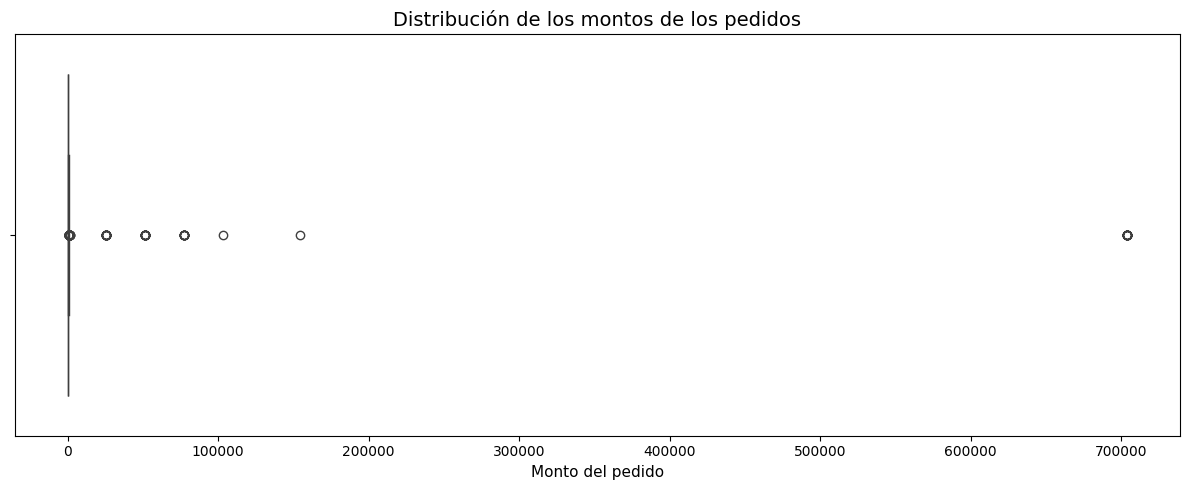

In [9]:
# ============================================================
#  DIAGRAMA DE CAJA Y BIGOTES (BOXPLOT)
# ============================================================

# Configuración del tamaño de la figura
plt.figure(figsize=(12, 5))

# Construcción del diagrama de caja
sns.boxplot(
    x=df['order_amount']
)

# Título y etiquetas
plt.title(
    'Distribución de los montos de los pedidos',
    fontsize=14
)

plt.xlabel(
    'Monto del pedido',
    fontsize=11
)

# Ajuste de la distribución visual
plt.tight_layout()

# Mostrar gráfico
plt.show()

## Interpretación
El diagrama de caja y bigotes se visualiza la distribución del order_amount, así como la aparición de valores distantes de la concentración central de los datos. Se observa una distribución con amplia dispersión y muchos valores atípicos en los montos más altos. El análisis basado en el rango intercuartílico, que detectó 141 valores atípicos (lo que equivale al 2,82 % de los registros), concuerda con esta conducta.

## **9.2. Gráfico de dispersión: relación entre cantidad de artículos y monto del pedido.**

La correlación entre dos variables cuantitativas puede ser analizada utilizando un gráfico de dispersión. En esta ocasión, se emplea order_amount como eje Y y total_items como eje X para analizar si hay alguna relación entre el valor total del pedido y el número de artículos comprados. Asimismo, posibilita la detección de agrupaciones de datos y observaciones que se encuentran distantes del comportamiento general.

### Variables utilizadas

- **Eje X:** `total_items` → cantidad de artículos incluidos en el pedido.
- **Eje Y:** `order_amount` → monto total del pedido.


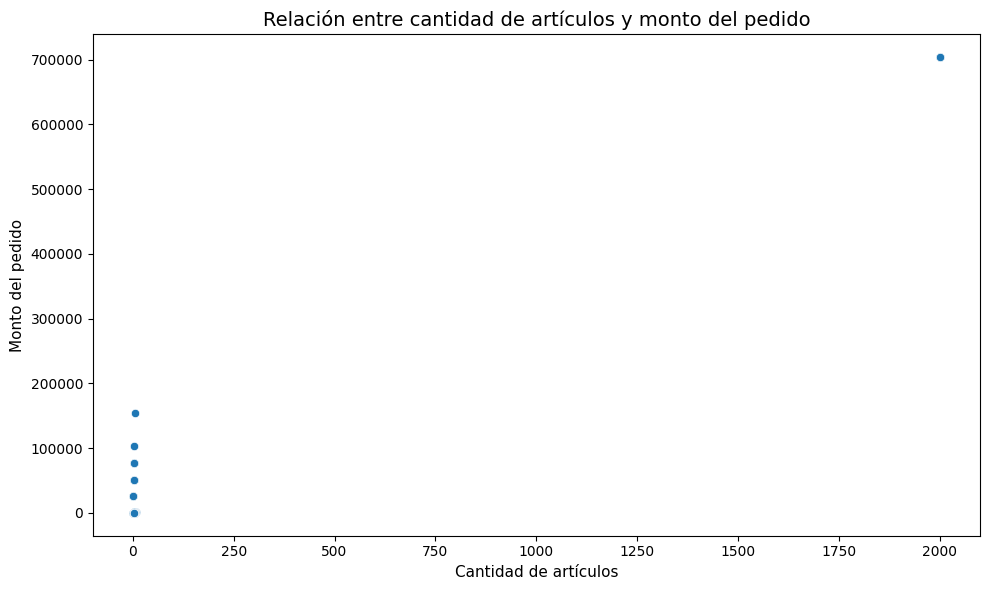

In [10]:
# ============================================================
# GRÁFICO DE DISPERSIÓN
# RELACIÓN ENTRE CANTIDAD DE ARTÍCULOS Y MONTO DEL PEDIDO
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='total_items',
    y='order_amount'
)

plt.title(
    'Relación entre cantidad de artículos y monto del pedido',
    fontsize=14
)

plt.xlabel(
    'Cantidad de artículos',
    fontsize=11
)

plt.ylabel(
    'Monto del pedido',
    fontsize=11
)

plt.tight_layout()
plt.show()

### Interpretación

La relación entre el monto del pedido (order_amount) y el número de artículos (total_items) se puede ver en el gráfico de dispersión. Se nota que las observaciones en valores bajos de cada una de las variables son muy numerosas, a pesar de que algunas se encuentran muy distantes del conjunto principal. Estas se refieren a órdenes con montos y cantidades mucho más altos que la tendencia general.

## **9.3. Visualización de los Datos mediante un Gráfico de Barras**
La representación gráfica de barras es un instrumento visual empleado para la comparación de cantidades entre categorías distintas. Este análisis permite la comparación de la cantidad total de pedidos dependiendo del método de pago empleado, lo que facilita la identificación de la categoría con el mayor volumen monetario.

### Parámetros empleados

- **`payment_method`**: variable categórica empleada para clasificar los pedidos.
- **`order_amount`**: variable numérica utilizada para calcular el monto total de los pedidos.
- **`groupby()`**: organiza los registros de acuerdo con el método de pago.
- **`sum()`**: determina el total de las órdenes por cada categoría.
- **`sns.barplot()`**: produce el gráfico de barras.
- **`plt.title()`**: define el título del gráfico.
- **`plt.xlabel()`**: marca el eje X.
- **`plt.ylabel()`**: marca el eje Y.

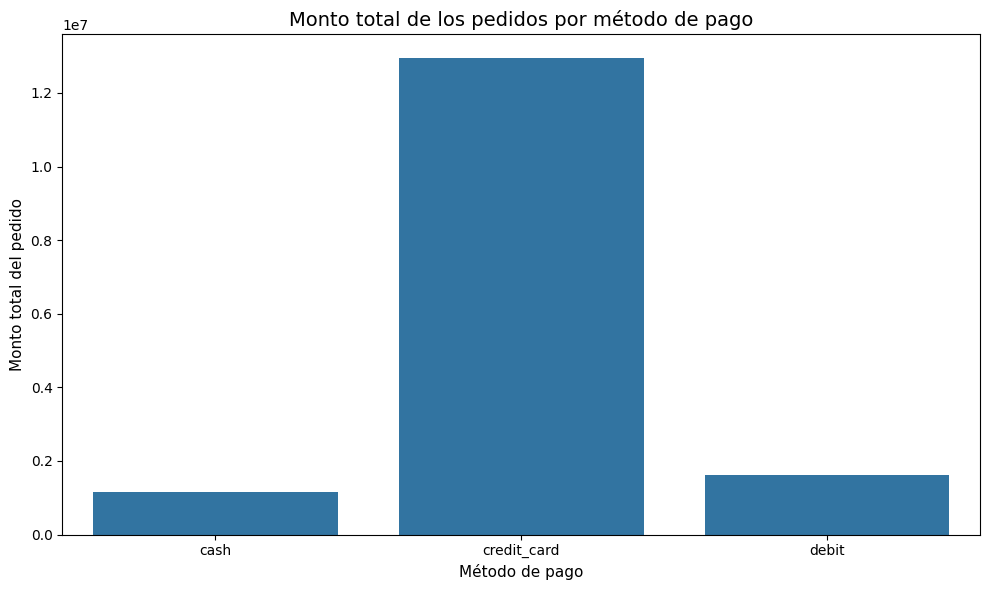

In [11]:
# ============================================================
# GRÁFICO DE BARRAS
# MONTO TOTAL DE LOS PEDIDOS POR MÉTODO DE PAGO
# ============================================================

# Agrupamos los pedidos según el método de pago
# y calculamos el monto total de cada categoría
payment_method_summary = (
    df.groupby('payment_method')['order_amount']
      .sum()
      .reset_index()
)

# Configuración del tamaño de la figura
plt.figure(figsize=(10, 6))

# Generación del gráfico de barras
sns.barplot(
    data=payment_method_summary,
    x='payment_method',
    y='order_amount'
)

# Título y etiquetas
plt.title(
    'Monto total de los pedidos por método de pago',
    fontsize=14
)

plt.xlabel(
    'Método de pago',
    fontsize=11
)

plt.ylabel(
    'Monto total del pedido',
    fontsize=11
)

# Ajuste de la presentación
plt.tight_layout()

# Mostrar gráfico
plt.show()

### Interpretación

La gráfica muestra que el método de pago con tarjeta de crédito abarca la mayor cantidad total de órdenes y está muy por encima del efectivo y la tarjeta de débito. El efectivo tiene el monto acumulado más bajo, mientras que el pago con tarjeta de débito tiene una participación intermedia. Esto demuestra que el valor de las transacciones es más alto cuando se hace mediante tarjeta de crédito.

## **10. Preprocesamiento de datos**

El preprocesamiento de datos incluye todas las técnicas que se implementan sobre un conjunto de datos antes de la creación de los modelos para la minería de datos. Su objetivo es optimizar la calidad, la coherencia y el uso de los datos a través de la detección y manejo de variables que necesitan cambios, registros repetidos, valores atípicos y valores ausentes. Durante esta fase, también es posible llevar a cabo procesos de generación de nuevas variables y codificación, con el fin de generar un conjunto de datos idóneo para las técnicas de modelado.

##**10.1 Identificación y tratamiento de duplicados**

Los datos duplicados son aquellos que se repiten dentro de un conjunto de información. La identificación es una fase crucial del preprocesamiento, pues la repetición de registros puede producir una representación errónea de los datos y perjudicar los resultados analíticos. Por esta razón, se comprueba su existencia antes de implementar métodos de modelado.

In [12]:
# ============================================================
#  IDENTIFICACIÓN Y TRATAMIENTO DE DUPLICADOS
# ============================================================

# Identificar registros duplicados
duplicados = df.duplicated()

# Calcular cantidad de duplicados
cantidad_duplicados = duplicados.sum()

# Calcular porcentaje de duplicados
porcentaje_duplicados = (cantidad_duplicados / len(df)) * 100

# Mostrar resultados
print("Cantidad de registros duplicados:", cantidad_duplicados)
print("Porcentaje de registros duplicados: {:.2f}%".format(
    porcentaje_duplicados
))

Cantidad de registros duplicados: 0
Porcentaje de registros duplicados: 0.00%


## Interpretación

El análisis de duplicados reveló que no hay registros repetidos en el conjunto de datos, ya que se encontraron 0 duplicados, lo cual representa el 0,00 % del total de observaciones. Por lo tanto, no se requirió eliminar ni consolidar registros en esta etapa del preprocesamiento, lo que permitió mantener las 5.000 observaciones originales para las etapas posteriores del análisis.

## **10.2 Tratamiento de Valores atipicos**
El proceso de identificar y manejar observaciones con valores notoriamente distintos al comportamiento general de un conjunto de datos se denomina tratamiento de valores atípicos. Estos valores tienen el potencial de impactar los resultados del análisis estadístico, así como también el rendimiento de los modelos predictivos.


In [13]:
# ============================================================
# TRATAMIENTO DE VALORES ATÍPICOS
# ============================================================

# Variable analizada
variable = 'order_amount'

# Calcular cuartiles
Q1 = df[variable].quantile(0.25)
Q3 = df[variable].quantile(0.75)

# Calcular rango intercuartílico
IQR = Q3 - Q1

# Establecer límites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("============================================")
print("TRATAMIENTO DE VALORES ATÍPICOS")
print("============================================")

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Límite inferior: {limite_inferior}")
print(f"Límite superior: {limite_superior}")

# Crear conjunto sin valores atípicos
df_sin_atipicos = df[
    (df[variable] >= limite_inferior) &
    (df[variable] <= limite_superior)
].copy()

# Comparación antes y después
registros_originales = len(df)
registros_finales = len(df_sin_atipicos)
registros_eliminados = registros_originales - registros_finales

porcentaje_eliminado = (
    registros_eliminados / registros_originales
) * 100

resumen_preprocesamiento = pd.DataFrame({
    'Etapa': [
        'Dataset original',
        'Después de eliminar atípicos'
    ],
    'Registros': [
        registros_originales,
        registros_finales
    ],
    'Registros eliminados': [
        0,
        registros_eliminados
    ],
    'Porcentaje respecto al original': [
        100,
        round((registros_finales / registros_originales) * 100, 2)
    ]
})

display(resumen_preprocesamiento)

print(f"\nTotal de registros eliminados: {registros_eliminados}")
print(f"Porcentaje de registros eliminados: {porcentaje_eliminado:.2f}%")

TRATAMIENTO DE VALORES ATÍPICOS
Q1: 163.0
Q3: 390.0
IQR: 227.0
Límite inferior: -177.5
Límite superior: 730.5


,Etapa,Registros,Registros eliminados,Porcentaje respecto al original
0,Dataset original,5000,0,100.00
1,Después de eliminar atípicos,4859,141,97.18



Total de registros eliminados: 141
Porcentaje de registros eliminados: 2.82%


## Interpretación


El manejo de los valores anómalos a través del rango intercuartílico (IQR) permitió detectar y descartar las observaciones de la variable `order_amount` que estaban fuera de los límites definidos.

El conjunto de datos contaba originalmente con 5000 registros. Tras el tratamiento, se retuvieron 4859 registros y se descartaron 141 observaciones consideradas anómalas.

Los 141 registros eliminados constituyen el 2,82 % del conjunto de datos inicial, mientras que el 97,18 % de las observaciones se conservó. Esto sugiere que el tratamiento tuvo un efecto menor sobre el tamaño del conjunto de datos, facilitando la reducción de la influencia de valores extremos sin perder una cantidad considerable de información.

## **10.3. Transformación Logaritmica**

Impacto que las variables extremas tienen en la distribución de los datos, dado que en la variable order_amount se encuentran valores atípicos. La transformación posibilita la compresión de la escala de los valores altos sin desechar las observaciones originales, lo que permite mantener la información existente en el conjunto de datos.

### Fórmula

La transformación que se lleva a cabo a través de `log1p()` es:

$$
X_{\text{log}} = \ln(1 + X)
$$

En donde:

- El valor original de `order_amount` es representado por **X**.
- $X_{\text{log}}$ señala el valor que ha sido transformado.
- **1 + X** se emplea para posibilitar la conversión de valores que son cero.




In [14]:
# ============================================================
# TRANSFORMACIÓN LOGARÍTMICA
# ============================================================

df_sin_atipicos['order_amount_log'] = np.log1p(
    df_sin_atipicos['order_amount']
)

print("Transformación logarítmica aplicada correctamente.")

display(
    df_sin_atipicos[
        ['order_amount', 'order_amount_log']
    ].head(10)
)

Transformación logarítmica aplicada correctamente.


,order_amount,order_amount_log
0,224,5.416100
1,90,4.510860
2,144,4.976734
3,156,5.056246
4,156,5.056246
5,138,4.934474
6,149,5.010635
7,292,5.680173
8,266,5.587249
9,146,4.990433


Interpretación

Se utilizó la función `log1p()` para transformar logarítmicamente la variable `order_amount`, con el objetivo de disminuir el impacto de los valores extremos y minimizar la asimetría de la distribución.

La variable `order_amount_log` es nueva y mantiene los datos de las cantidades de las órdenes, aunque en una escala logarítmica. Por ejemplo, 224 se convierte aproximadamente en 5.416100.

Esta conversión se empleará como variable objetivo en el modelado, lo que permitirá utilizar una distribución más apropiada para los algoritmos de regresión.

## **10.4 Codificación de payment_method**
La variable payment_method es una variable categórica que señala el método de pago usado en cada orden. Con el objetivo de simplificar su empleo en los algoritmos de modelado, se creó la variable payment_method_code, que asigna un código numérico a cada una de las categorías. Con el fin de que los resultados sean más fáciles de interpretar, se mantiene la variable original.

In [15]:
# ============================================================
# CODIFICACIÓN DE payment_method
# ============================================================

# Convertir la variable categórica a tipo category
df_sin_atipicos['payment_method'] = (
    df_sin_atipicos['payment_method'].astype('category')
)

# Crear códigos numéricos
df_sin_atipicos['payment_method_code'] = (
    df_sin_atipicos['payment_method'].cat.codes
)

# Mostrar correspondencia entre categorías y códigos
tabla_codificacion = (
    df_sin_atipicos[
        ['payment_method', 'payment_method_code']
    ]
    .drop_duplicates()
    .sort_values('payment_method_code')
    .reset_index(drop=True)
)

display(tabla_codificacion)

# Mostrar cantidad de categorías
print(
    "Cantidad de métodos de pago:",
    df_sin_atipicos['payment_method'].nunique()
)

# Verificar valores nulos
print(
    "Valores nulos en payment_method_code:",
    df_sin_atipicos['payment_method_code'].isnull().sum()
)

,payment_method,payment_method_code
0,cash,0
1,credit_card,1
2,debit,2


Cantidad de métodos de pago: 3
Valores nulos en payment_method_code: 0


Interpretación

`payment_method`, la variable categórica, tiene tres métodos de pago: `cash`, `debit` y `credit_card`. Se llevó a cabo una codificación numérica usando `cat.codes` para poder aplicar esta información en los modelos de minería de datos.

Los datos que se obtuvieron fueron los siguientes: `cash = 0`, `credit_card = 1` y `debit = 2`. Asimismo, se constató que la variable codificada no tiene valores nulos, lo cual permite su uso como variable predictora en el modelado.

# 10.5 Feature Engineering

Es el proceso de generar nuevas variables a partir de las variables iniciales de un conjunto de datos con el fin de adquirir información adicional que sea provechosa para el modelado y el análisis.

En este caso, se empleó la variable temporal `created_at` para crear otras dos variables: `order_dayofweek` y `order_month`. Estas variables posibilitan representar la conducta temporal de las órdenes de una manera que puede ser empleada más adelante por los algoritmos de minería de datos.

In [16]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

# Convertir la fecha a formato datetime
df_sin_atipicos['created_at'] = pd.to_datetime(
    df_sin_atipicos['created_at']
)

# Crear variables derivadas a partir de la fecha
df_sin_atipicos['order_dayofweek'] = (
    df_sin_atipicos['created_at'].dt.dayofweek
)

df_sin_atipicos['order_month'] = (
    df_sin_atipicos['created_at'].dt.month
)

# Mostrar únicamente la fecha y las variables derivadas
display(
    df_sin_atipicos[
        ['created_at', 'order_dayofweek', 'order_month']
    ].head(10)
)

,created_at,order_dayofweek,order_month
0,2017-03-13 12:36:56,0,3
1,2017-03-03 17:38:52,4,3
2,2017-03-14 04:23:56,1,3
3,2017-03-26 12:43:37,6,3
4,2017-03-01 04:35:11,2,3
5,2017-03-14 15:25:01,1,3
6,2017-03-01 21:37:57,2,3
7,2017-03-08 02:05:38,2,3
8,2017-03-17 20:56:50,4,3
9,2017-03-30 21:08:26,3,3


### Interpretación

Se genera dos variables a partir de created_at.

La variable order_dayofweek indica el día de la semana en que se realizó el pedido, cuyo rango de valores va de 0 (lunes) a 6 (domingo). Se pueden ver ejemplos como 0, 1, 2, 4 y 6.

La variable order_month indica el mes de la transacción, cuyo valor es 3, lo que equivale al mes de marzo.

Estas variables colaboran en la modelización predictiva y en el análisis.

## **11. Modelado**

El modelado es la fase en la que se utilizan algoritmos de aprendizaje automático en los datos que han sido procesados anteriormente, con el fin de predecir la variable objetivo y evaluar el rendimiento de varios métodos predictivos.
Al tratarse de order_amount_log como una variable cuantitativa continua, se plantea el asunto como un problema de regresión.
Para este análisis se eligieron tres algoritmos: Regresión Lineal, Random Forest Regressor y Gradient Boosting Regressor. La elección pretende contrastar un modelo lineal de referencia con dos enfoques que utilizan árboles, los cuales pueden capturar relaciones no lineales y más complejas entre las variables.

La regresión Lineal se emplea como modelo de comparación por su claridad y facilidad de interpretación. Facilita la creación de un punto de partida para evaluar si modelos más complejos pueden superar la capacidad de predicción.
El Random Forest Regressor se incorpora al análisis ya que une varios árboles de decisión y es capaz de identificar interacciones no lineales entre las variables independientes, proporcionando una opción más adaptable en contraste con el modelo lineal.
Finalmente, se elige el Gradient Boosting Regressor ya que crea los árboles de forma sucesiva, y disminuir poco a poco los errores en las predicciones. Este enfoque ofrece la oportunidad de evaluar si una técnica de aprendizaje en secuencia puede lograr un rendimiento superior al de la regresión lineal y Random Forest.
La evaluación de estos tres algoritmos ofrece la posibilidad de identificar cuál de ellos logra el mejor balance entre la precisión en las predicciones y la habilidad de explicación para el conjunto de datos estudiado.


## **11.1 División del conjunto de datos**

El conjunto de datos se fraccionó en un 80 % para el entrenamiento y en un 20 % para la prueba. El conjunto de entrenamiento sirve para ajustar los modelos, y el de prueba se emplea para valorar su habilidad predictiva en observaciones que no fueron incluidas en el entrenamiento. Se estableció random_state=42 con el fin de asegurar que la división sea reproducible.

In [17]:
# ============================================================
# DIVISIÓN DEL CONJUNTO DE DATOS
# ============================================================

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# 1. Selección de las variables
# ------------------------------------------------------------

# Variables predictoras
X = df_sin_atipicos[
    [
        'total_items',
        'payment_method_code',
        'order_dayofweek',
        'order_month'
    ]
]

# Variable objetivo
y = df_sin_atipicos['order_amount_log']

# ------------------------------------------------------------
# 2. División de los datos
# ------------------------------------------------------------

# 80 % para entrenamiento y 20 % para prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ------------------------------------------------------------
# 3. Verificación de los conjuntos
# ------------------------------------------------------------

print("============================================")
print("DIVISIÓN DEL CONJUNTO DE DATOS")
print("============================================")

print(f"Total de observaciones: {len(X)}")
print(f"Observaciones para entrenamiento: {len(X_train)}")
print(f"Observaciones para prueba: {len(X_test)}")

print("\nDimensiones de los datos:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

# ------------------------------------------------------------
# 4. Mostrar las primeras observaciones
# ------------------------------------------------------------

print("\nPrimeras observaciones del conjunto de entrenamiento:")
display(X_train.head())

print("\nPrimeras observaciones de la variable objetivo:")
display(y_train.head())

DIVISIÓN DEL CONJUNTO DE DATOS
Total de observaciones: 4859
Observaciones para entrenamiento: 3887
Observaciones para prueba: 972

Dimensiones de los datos:
X_train: (3887, 4)
X_test : (972, 4)
y_train: (3887,)
y_test : (972,)

Primeras observaciones del conjunto de entrenamiento:


,total_items,payment_method_code,order_dayofweek,order_month
4271,1,1,5,3
2360,4,0,4,3
1878,3,1,0,3
3629,2,1,3,3
185,2,2,3,3



Primeras observaciones de la variable objetivo:


,order_amount_log
4271,5.087596
2360,6.255750
1878,6.230481
3629,5.872118
185,5.796058


# Interpretación

La función train_test_split se utilizó para dividir el conjunto de datos, separando un 80 % para el entrenamiento y un 20 % para la prueba, con random_state=42 para garantizar que el proceso fuera reproducible. La variable objetivo es order_amount_log, y las variables predictoras son total_items, payment_method_code, order_dayofweek y order_month. El conjunto de entrenamiento modificará los modelos de regresión, mientras que el conjunto de prueba medirá su rendimiento. Asimismo, order_month tiene un valor de 3, lo que señala una baja variación durante el mes de marzo.

## **11.2 Modelo de Regresión Lineal**

La regresión lineal es un método de aprendizaje supervisado que se emplea para examinar y calcular la relación entre una variable dependiente y una o más variables independientes. El modelo busca encontrar una combinación lineal de las variables predictoras que permita aproximarse al valor de la variable objetivo.

En este proyecto se utiliza la regresión lineal como modelo de referencia para predecir `order_amount_log` a partir de las variables `total_items`, `payment_method_code`, `order_dayofweek` y `order_month`.

### Fórmula general

La regresión lineal múltiple puede expresarse como:

$$
\hat{y} = \beta_0 + \beta_1X_1 + \beta_2X_2 + \cdots + \beta_pX_p
$$

Donde:

- $\hat{y}$ = valor estimado de la variable objetivo.
- $\beta_0$ = intercepto.
- $\beta_i$ = coeficientes asociados a las variables predictoras.
- $X_i$ = variables predictoras.
- $p$ = número de variables predictoras.


In [18]:
# ============================================================
# MODELO DE REGRESIÓN LINEAL
# ============================================================

from sklearn.linear_model import LinearRegression

# ------------------------------------------------------------
# 1. Crear el modelo
# ------------------------------------------------------------

modelo_lr = LinearRegression()

# ------------------------------------------------------------
# 2. Entrenar el modelo
# ------------------------------------------------------------

modelo_lr.fit(X_train, y_train)

# ------------------------------------------------------------
# 3. Realizar predicciones sobre los datos de prueba
# ------------------------------------------------------------

y_pred_lr = modelo_lr.predict(X_test)

print("Modelo de Regresión Lineal entrenado correctamente.")

Modelo de Regresión Lineal entrenado correctamente.


# Interpretación

Se utilizó un método de Regresión Lineal con las variables elegidas para predecir y la variable meta `order_amount_log`.

El entrenamiento del modelo se llevó a cabo con el 80 % de los datos reservados para esta fase y, después, se realizaron las predicciones en el 20 % que correspondía al conjunto de prueba.

Las predicciones que se generaron se emplearán más adelante para calcular las métricas MAE, RMSE y R² y así valorar el rendimiento del modelo.

## **11.3 Modelo Random Forest Regressor**

Random Forest Regressor es un algoritmo de aprendizaje supervisado que usa múltiples árboles de decisión para hacer predicciones, combinando sus resultados para mayor estabilidad y menos riesgo. En este proyecto, se usa para predecir la variable objetivo order_amount_log a partir de las variables total_items, payment_method_code, order_dayofweek y order_month. Los parámetros incluyen n_estimators=100 para construir 100 árboles y random_state=42 para reproducibilidad. Se eligió este modelo por su capacidad para identificar relaciones no lineales, lo que permite compararlo con la regresión lineal en su desempeño.

In [19]:
# ============================================================
# MODELO RANDOM FOREST REGRESSOR
# ============================================================

from sklearn.ensemble import RandomForestRegressor

# Crear el modelo
modelo_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Entrenar el modelo
modelo_rf.fit(X_train, y_train)

# Realizar predicciones sobre los datos de prueba
y_pred_rf = modelo_rf.predict(X_test)

print("Modelo Random Forest entrenado correctamente.")

Modelo Random Forest entrenado correctamente.


# Interpretación
El modelo Random Forest Regressor fue entrenado correctamente con el conjunto de datos de entrenamiento. Se estableció `random_state=42` con el fin de asegurar que el proceso fuera reproducible y se emplearon 100 árboles de decisión para su elaboración.

Después, el modelo llevó a cabo pronósticos sobre el conjunto de prueba. Se emplearán estas previsiones para determinar las métricas MAE, RMSE y R² y cotejar su rendimiento con el modelo de Gradient Boosting y con el de Regresión Lineal.

## **11.4 Modelo Gradient Boosting Regressor**
Gradient Boosting Regressor es un algoritmo de aprendizaje supervisado que genera modelos de forma sucesiva. La capacidad para predecir se incrementa a medida que cada nuevo árbol corrige los errores de los anteriores. Se emplea en este proyecto para prever order_amount_log con variables tales como total_items, payment_method_code, order_dayofweek y order_month. Se estableció con una profundidad máxima de 3, un estado aleatorio de 42, una tasa de aprendizaje de 0.1 y 100 árboles. Se eligió este modelo debido a su capacidad para modelar relaciones no lineales y optimizar las predicciones, lo que posibilitó compararlo con Random Forest y Regresión Lineal.

In [20]:
# ============================================================
# MODELO GRADIENT BOOSTING REGRESSOR
# ============================================================

from sklearn.ensemble import GradientBoostingRegressor

# Crear el modelo
modelo_gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Entrenar el modelo
modelo_gb.fit(X_train, y_train)

# Realizar predicciones sobre los datos de prueba
y_pred_gb = modelo_gb.predict(X_test)

print("Modelo Gradient Boosting entrenado correctamente.")

Modelo Gradient Boosting entrenado correctamente.


# Interpretación

Los datos de entrenamiento se utilizaron para entrenar adecuadamente el modelo Gradient Boosting Regressor. Se establecieron 100 árboles, una tasa de aprendizaje del 10% y una profundidad máxima de tres niveles.

Después de ser entrenado, el modelo realizó pronósticos sobre el conjunto de prueba. Más adelante se emplearán estas predicciones para determinar las métricas MAE, RMSE y R².

In [21]:
import joblib

# Guardar el modelo Gradient Boosting
joblib.dump(modelo_gb, "modelo_gradient_boosting.joblib")

print("Modelo guardado correctamente.")

Modelo guardado correctamente.


## **12. Evaluación y validación de los modelos**
La validación y la evaluación facilitan el establecimiento del rendimiento de los modelos de regresión que se han creado. Para eso, se emplean métricas que posibilitan calcular el error de las predicciones y establecer qué porcentaje de la variabilidad del objetivo puede ser explicado por cada modelo. En este proyecto, las métricas MAE, RMSE y R² se calculan a partir del conjunto de datos de prueba.

## **12.1 Evaluación de la Regresión Lineal**

El propósito de la evaluación de un modelo de regresión lineal es establecer cuán eficazmente el modelo puede prever una variable dependiente, basándose en una o más variables independientes. Para lograr esto, se comparan los valores reales de la variable objetivo con las cifras que el modelo predice.

### Fundamentación de las métricas

**MAE — Error Absoluto Medio**

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|
$$

El MAE es la media de las discrepancias absolutas entre los valores pronosticados y los reales. **El error promedio del modelo disminuye cuando el MAE es menor.**

**RMSE — Raíz del Error Cuadrático Medio**

$$
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}
$$

El RMSE brinda una medición del error de predicción y concede más importancia a los errores de mayor magnitud. **Un rendimiento predictivo superior se indica con un valor más bajo.**

**R² — Coeficiente de determinación**

$$
R^2 = 1-\frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i-\bar{y})^2}
$$

El R² revela el porcentaje de la variabilidad del objetivo que el modelo es capaz de explicar. Su valor puede oscilar entre valores negativos y 1, donde **1 representa un ajuste perfecto**.

In [22]:
# ============================================================
# EVALUACIÓN DEL MODELO DE REGRESIÓN LINEAL
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# Calcular métricas
mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

r2_lr = r2_score(y_test, y_pred_lr)

# Mostrar resultados
print("Resultados - Regresión Lineal")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R²:", r2_lr)

Resultados - Regresión Lineal
MAE: 0.1519560547509838
RMSE: 0.19862961731911496
R²: 0.8357695308340256


# Interpretación

Las métricas obtenidas permite la evaluación del rendimiento del modelo de regresión lineal en el conjunto de prueba. El modelo logró un MAE de 0.15196, lo que significa que el error absoluto promedio entre los valores pronosticados y los reales de order_amount_log es en torno a 0.152 unidades. El RMSE fue de 0.19863, lo que indica que existen algunos errores con mayor magnitud. El modelo explica cerca del 83,58 % de la variabilidad de order_amount_log, según el R² obtenido, que fue de 0.83576.


##**12.2 Evaluación del modelo Random Forest**

En el conjunto de datos de prueba, se usa MAE, RMSE y R² para evaluar el modelo Random Forest Regressor. Estos indicadores posibilitan el cálculo del nivel de error en las predicciones y la habilidad del modelo para aclarar la variabilidad de order_amount_log, la variable objetivo.

In [23]:
# ============================================================
# EVALUACIÓN DEL MODELO RANDOM FOREST
# ============================================================

mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("Resultados - Random Forest")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

Resultados - Random Forest
MAE: 0.1374630138027016
RMSE: 0.17507854342932766
R²: 0.8724056125087611


# Interpretación

El modelo Random Forest obtuvó un MAE de 0.13746, lo que señala que el error absoluto medio es de cerca de 0.137 unidades en la escala logarítmica para order_amount_log. El error de predicción fue más bajo que el de la regresión lineal, ya que el RMSE fue 0.17508. El modelo llegó a un R² de 0.87241, lo que significa que las variables empleadas explican alrededor del 87.24 % de la variabilidad de order_amount_log.

## **12.3 Evaluación del modelo Gradient Boosting**
En modelo Gradient Boosting Regressor se examina el conjunto de datos de prueba a través de las métricas MAE, R² y RMSE. Estos indicadores posibilitan establecer la magnitud de error en las predicciones y el grado de explicación del modelo con relación a la variable objetivo order_amount_log.

In [24]:
# ============================================================
# EVALUACIÓN DEL MODELO GRADIENT BOOSTING
# ============================================================

mae_gb = mean_absolute_error(y_test, y_pred_gb)

rmse_gb = np.sqrt(
    mean_squared_error(y_test, y_pred_gb)
)

r2_gb = r2_score(y_test, y_pred_gb)

print("Resultados - Gradient Boosting")
print("MAE:", mae_gb)
print("RMSE:", rmse_gb)
print("R²:", r2_gb)

Resultados - Gradient Boosting
MAE: 0.13664383474039235
RMSE: 0.17385114067696028
R²: 0.8741883636858812


# Interpretación

El modelo Gradient Boosting alcanzó un MAE (Error Absoluto Medio)de 0.13664, lo cual indica que el error medio de las predicciones en la escala logarítmica es de alrededor de 0.137 unidades. El RMSE(Raíz del Error Cuadrático Medio) fue de 0.17385, lo que indica que el error de predicción fue inferior al de Random Forest. Asimismo, el modelo alcanzó un R²(Coeficiente de Determinación) de 0.87419, lo que significa que las variables empleadas explican cerca del 87.42 % de la variabilidad de order_amount_log. Gradient Boosting sobresale como el modelo con mayor capacidad predictiva, pues tiene el MAE y el RMSE más bajos, así como el R² más alto de los modelos analizados.

## **12.4. Comparación de los modelos**

En esta fase, se contrastan los resultados que han producido los tres modelos de regresión implementados: Regresor de bosque aleatorio, regresor de gradiente y regresión lineal. Se utilizan las métricas RMSE, MAE y R² para comparar y averiguar cuál de los modelos tiene el mejor rendimiento predictivo sobre el conjunto de prueba.

Para MAE y RMSE, los valores más bajos significan un error de predicción menor. En cambio, para R², si el valor es más alto implica que el modelo tiene mayor capacidad para aclarar la variabilidad de la variable objetivo.

In [25]:
# ============================================================
# COMPARACIÓN DE LOS TRES MODELOS
# ============================================================

resultados_modelos = pd.DataFrame({
    'Modelo': [
        'Regresión Lineal',
        'Random Forest',
        'Gradient Boosting'
    ],
    'MAE': [
        mae_lr,
        mae_rf,
        mae_gb
    ],
    'RMSE': [
        rmse_lr,
        rmse_rf,
        rmse_gb
    ],
    'R²': [
        r2_lr,
        r2_rf,
        r2_gb
    ]
})

display(resultados_modelos)

,Modelo,MAE,RMSE,R²
0,Regresión Lineal,0.151956,0.198630,0.835770
1,Random Forest,0.137463,0.175079,0.872406
2,Gradient Boosting,0.136644,0.173851,0.874188


# Interpretación
Al comparar los tres modelos, se pueden observar las diferencias en su desempeño de predicción. La Regresión Lineal mostró un MAE de 0.15196, un RMSE de 0.19863 y un R² de 0.83577, lo que indica que fue el modelo con peor rendimiento. El modelo Random Forest superó a la regresión lineal, con un MAE de 0.13746, un RMSE de 0.17508 y un R² de 0.87241. En conclusión, Gradient Boosting tuvo el mejor desempeño predictivo de los tres modelos, logrando un MAE de 0.13664, un RMSE de 0.17385 y un R² de 0.87419.

##**12.5 Validación Cruzada**
Una técnica empleada para evaluar la capacidad de generalización y estabilidad de un modelo es la validación cruzada. En este procedimiento, el conjunto de datos se fracciona en diversas particiones o folds. En cada paso, se usa una porción para evaluar el modelo y las demás para capacitarlo. Este procedimiento se repite hasta que todas las particiones se usan como conjuntos de validación y, al final, se calcula el promedio de las métricas adquiridas.

In [26]:
# ============================================================
# VALIDACIÓN CRUZADA DE LOS MODELOS
# ============================================================

from sklearn.model_selection import KFold, cross_validate

# Configuración de la validación cruzada
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Modelos a evaluar
modelos = {
    'Regresión Lineal': modelo_lr,
    'Random Forest': modelo_rf,
    'Gradient Boosting': modelo_gb
}

# Almacenar resultados
resultados_cv = []

# Evaluar cada modelo mediante validación cruzada
for nombre, modelo in modelos.items():

    resultados = cross_validate(
        modelo,
        X,
        y,
        cv=cv,
        scoring={
            'mae': 'neg_mean_absolute_error',
            'rmse': 'neg_root_mean_squared_error',
            'r2': 'r2'
        }
    )

    resultados_cv.append({
        'Modelo': nombre,
        'MAE promedio': -resultados['test_mae'].mean(),
        'RMSE promedio': -resultados['test_rmse'].mean(),
        'R² promedio': resultados['test_r2'].mean()
    })

# Crear tabla de resultados
tabla_cv = pd.DataFrame(resultados_cv)

# Mostrar resultados
display(tabla_cv)

,Modelo,MAE promedio,RMSE promedio,R² promedio
0,Regresión Lineal,0.161611,0.208929,0.824516
1,Random Forest,0.138033,0.176918,0.874226
2,Gradient Boosting,0.137300,0.175980,0.875559


# Interpretación
La validación cruzada se llevó a cabo utilizando 5 particiones para analizar tres modelos diferentes. La Regresión Lineal alcanzó un MAE promedio de 0. 16161, un RMSE de 0. 20893 y un R² de 0. 82452, evidenciando el rendimiento más bajo. El modelo de Random Forest logró un MAE de 0. 13803, un RMSE de 0. 17692 y un R² de 0. 87423, superando las cifras de la Regresión Lineal. Finalmente, el modelo de Gradient Boosting registró un MAE de 0. 13730, un RMSE de 0. 17598 y un R² de 0. 87556, destacándose como el más eficaz entre los tres modelos analizados.

## **12.6 Comparación gráfica de los modelos**
Es posible ilustrar visualmente el rendimiento de los modelos de Regresión Lineal, Random Forest y Gradient Boosting a través de las métricas adquiridas a de la validación cruzada mediante la comparación gráfica. Esta representación hace más fácil encontrar el modelo que tiene la menor tasa de error de predicción y la mayor capacidad de explicación.

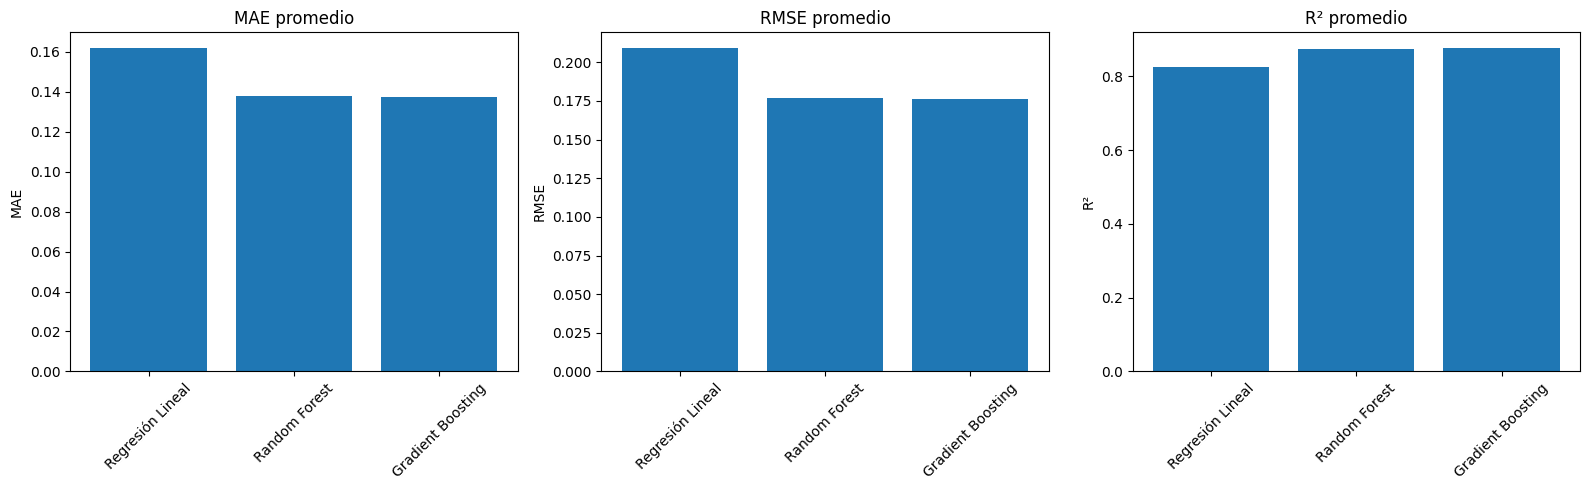

In [27]:
# ============================================================
# COMPARACIÓN GRÁFICA DE LOS MODELOS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ------------------------------------------------------------
# MAE
# ------------------------------------------------------------

axes[0].bar(
    tabla_cv['Modelo'],
    tabla_cv['MAE promedio']
)

axes[0].set_title('MAE promedio')
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=45)

# ------------------------------------------------------------
# RMSE
# ------------------------------------------------------------

axes[1].bar(
    tabla_cv['Modelo'],
    tabla_cv['RMSE promedio']
)

axes[1].set_title('RMSE promedio')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=45)

# ------------------------------------------------------------
# R²
# ------------------------------------------------------------

axes[2].bar(
    tabla_cv['Modelo'],
    tabla_cv['R² promedio']
)

axes[2].set_title('R² promedio')
axes[2].set_ylabel('R²')
axes[2].tick_params(axis='x', rotation=45)

# Ajustar presentación
plt.tight_layout()

# Mostrar gráficos
plt.show()

# Interpretación

Los gráficos ilustran el rendimiento promedio de tres modelos usando las métricas MAE, RMSE y R² en la validación cruzada de cinco particiones. La regresión lineal presenta el valor más elevado en el gráfico de MAE, con 0.16161; Random Forest tiene 0.13803 y Gradient Boosting, con 0.13730, es el mejor de los tres. La regresión lineal presenta un RMSE de 0.20893, Random Forest tiene 0.17692 y Gradient Boosting muestra un RMSE de 0.17598, siendo esta última la primera en el ranking una vez más. La Regresión Lineal, Random Forest y Gradient Boosting logran en R² 0.82452, 0.87423 y 0.87556 respectivamente, repetidos estos últimos dos como los mejores desempeños. En síntesis, Gradient Boosting es el modelo más eficiente, después se encuentra Random Forest y por último la Regresión Lineal.

## **12.7 Parámetros de los modelos**

Los parámetros de un modelo de aprendizaje automático son ajustes que definen cómo el algoritmo lleva a cabo el proceso de aprendizaje. Al registrar estos parámetros, se documentan las condiciones en las que los modelos fueron entrenados y esto permite que los resultados conseguidos puedan ser reproducidos y comparados.

In [28]:
# ============================================================
# PARÁMETROS PRINCIPALES DE LOS MODELOS
# ============================================================

parametros_modelos = pd.DataFrame({
    'Modelo': [
        'Regresión Lineal',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Parámetros principales': [
        'Sin parámetros adicionales',
        'n_estimators=100, random_state=42',
        'n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42'
    ]
})

display(parametros_modelos)

,Modelo,Parámetros principales
0,Regresión Lineal,Sin parámetros adicionales
1,Random Forest,"n_estimators=100, random_state=42"
2,Gradient Boosting,"n_estimators=100, learning_rate=0.1, max_depth..."


# Interpretación

La tabla permite documentar las configuraciones más significativas utilizadas en el entrenamiento de los tres modelos. Random Forest fue configurado con 100 árboles y una semilla aleatoria de 42, mientras que la configuración estándar se empleó en la regresión lineal. Se definieron 100 estimadores, una tasa de aprendizaje de 0,1, una profundidad máxima de 3 y una semilla aleatoria de 42 para el método Gradient Boosting. Al registrar estos parámetros, se puede documentar las condiciones experimentales que se usaron y se mejora la posibilidad de repetir el análisis.

In [29]:
import sklearn
import numpy
import scipy
import joblib

print("scikit-learn:", sklearn.__version__)
print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("joblib:", joblib.__version__)

scikit-learn: 1.6.1
numpy: 2.1.3
scipy: 1.16.3
joblib: 1.6.0


## **13. Resumen del modelado**

De acuerdo con los resultados obtenidos, se puede afirmar que los tres modelos tienen la capacidad de anticipar la variable `order_amount_log`. No obstante, Gradient Boosting Regressor demostró ser el más efectivo en general, al lograr los valores más reducidos de MAE y RMSE, así como el índice más alto de R² en el análisis del conjunto de prueba y en la validación cruzada de cinco divisiones.

Por su parte, Random Forest mostró un desempeño similar al de Gradient Boosting, mientras que la Regresión Lineal presentó los resultados menos favorables entre los modelos analizados. La uniformidad de los resultados en ambas evaluaciones facilita la elección de Gradient Boosting como el modelo con el mejor rendimiento predictivo para el conjunto de datos examinados.